# Reciprocal Rank Fusion (RRF)

## 1. Concept - How RRF solves the problem in multi-query retrieval?

Reciprocal Rank Fusion (RRF) is a method that combines multiple ranked chunk lists by giving each chunk a RRF score based on its positions across all lists.

$$
\text{RRF\_score} = \sum \left(\frac{1}{k + \text{rank\_position}}\right)
$$

Where:
- `k` is a constant (typically **60**)
- `rank_position` is the position of the chunk in a query retrieval result
- The sum is across all queries where the chunks appear

## 2. RRF Scenario (k = 0)

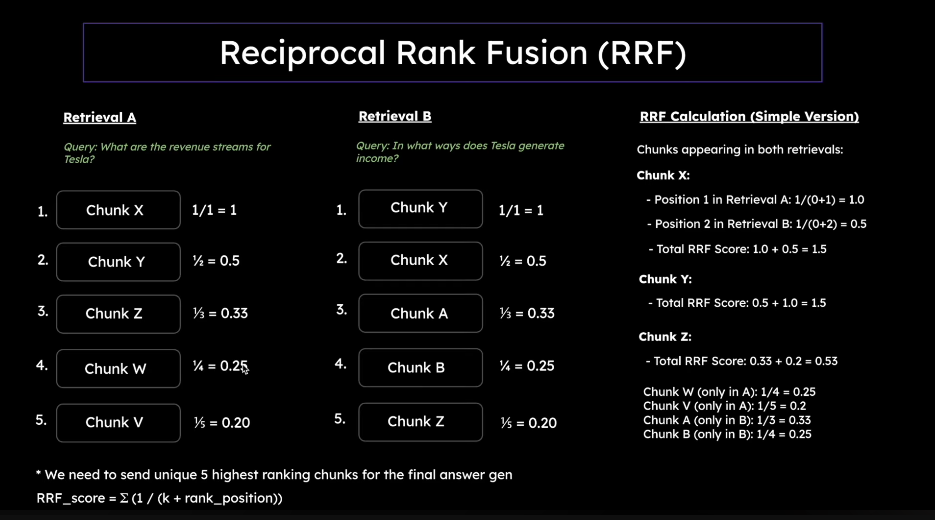
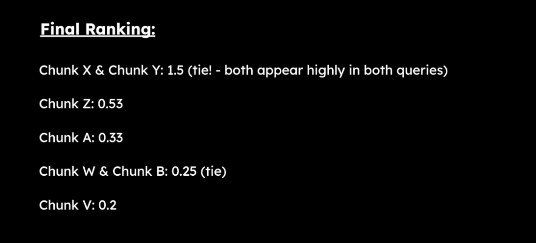

### 2.1 The Problems with k = 0

Notice how dramatic the score differences are:
- Position **1** gets score **1.0**
- Position **2** gets score **0.5** (*50% penalty!*)
- Position **3** gets score **0.33** (*67% penalty!*)
  
**Real-World Issue:**
> 
> In our example, **Chunk X** and **Chunk Y** might have had very similar similarity scores (*0.95* vs. *0.94* in Retrieval A).
> 
> That tiny *0.01* difference in similarity gets amplified into a **2x** scoring difference (*1.0* vs. *0.5*) in RRF!


This means we're treating a **1%** similarity difference as if one document is twice as good as the other. That's problematic because:
- We're **over-penalizing lower positions**
- Small differences in similarity scores often don't reflect meaningful relevance differences

## 3. RRF Scenario (k = 60)

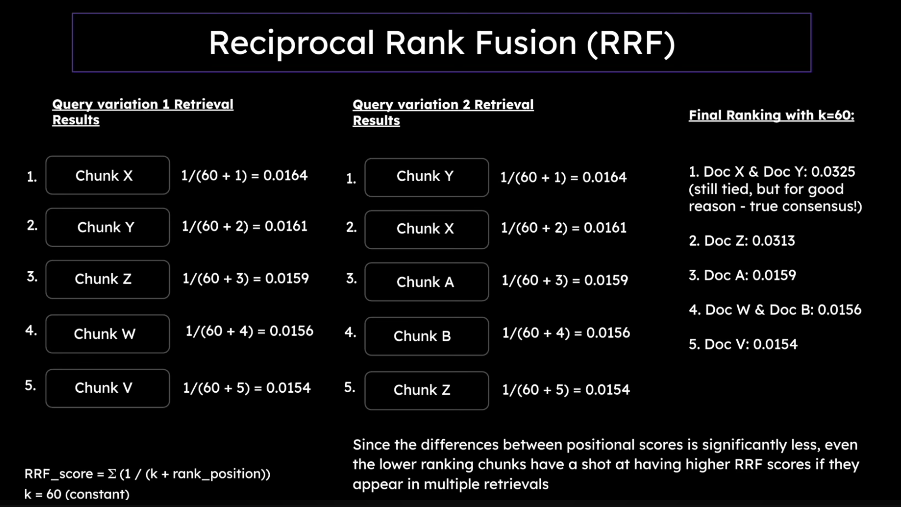


## 4. Key Takeaways

1. RRF boosts chunks that appear in multiple query results - this is the *consensus* effect
2. `k=0` is too harsh - It over-emphasizes top positions and under-values lower position
3. `k=60` provides balance - top positions still matter, but the differences are more reasonable (widely used in popular projects)